# 项目：天猫订单综合分析

## 1. 分析目标：
1. 计算订单每个环节的转化率
2. 可视化订单成交的时间（按天）趋势(按实际成交）
3. 可视化订单数在地图上的分布


## 2. 数据说明
本数据集共收集了发生在一个月内的28010条数据，包含以下：  
订单编号、总金额、买家实际支付金额、收货地址、订单创建时间、订单付款时间 、退款金额

7个字段说明：
- 订单编号：订单编号
- 总金额：订单总金额
- 买家实际支付金额：总金额 - 退款金额（在已付款的情况下）。金额为0（在未付款的情况下）
- 收货地址：各个省份
- 订单创建时间：下单时间
- 订单付款时间：付款时间
- 退款金额：付款后申请退款的金额。如无付过款，退款金额为0


## 3. 数据分析前准备
### 3.1 导入数据库

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import matplotlib.dates as mdates

### 3.2 设置图像字体

In [2]:
import matplotlib
matplotlib.rc("font",family=' Microsoft YaHei')

### 3.3 读取数据

In [3]:
original_data=pd.read_csv(r"C:\Users\ZhuanZ（无密码）\Desktop\数据分析集\天猫订单综合分析\tmall_order_report.csv")

## 4. 数据评估和清理
结构问题判断：每个变量是否为一列，每个观察值是否为一行，每种类型的观察值是否为一个单元格  
内容问题判断：有无丢失数据、重复数据、不一致数据、无效或错误数据

### 4.1 结构问题

In [4]:
clean_data=original_data.copy()
clean_data.head(10)

,订单编号,总金额,买家实际支付金额,收货地址,订单创建时间,订单付款时间,退款金额
0,1,178.8,0.0,上海,2020-02-21 00:00:00,NaN,0.0
1,2,21.0,21.0,内蒙古自治区,2020-02-20 23:59:54,2020-02-21 00:00:02,0.0
2,3,37.0,0.0,安徽省,2020-02-20 23:59:35,NaN,0.0
3,4,157.0,157.0,湖南省,2020-02-20 23:58:34,2020-02-20 23:58:44,0.0
4,5,64.8,0.0,江苏省,2020-02-20 23:57:04,2020-02-20 23:57:11,64.8
5,6,327.7,148.9,浙江省,2020-02-20 23:56:39,2020-02-20 23:56:53,178.8
6,7,357.0,357.0,天津,2020-02-20 23:56:36,2020-02-20 23:56:40,0.0
7,8,53.0,53.0,浙江省,2020-02-20 23:56:12,2020-02-20 23:56:16,0.0
8,9,43.0,0.0,湖南省,2020-02-20 23:54:53,2020-02-20 23:55:04,43.0
9,10,421.0,421.0,北京,2020-02-20 23:54:28,2020-02-20 23:54:33,0.0


从头部的10行数据来看，数据符合“每行是同一个观察者，每列是同一个变量，每个单元格是一个值”，因此不存在结构性问题。

### 4.2 内容问题

In [5]:
clean_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 28010 entries, 0 to 28009
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   订单编号      28010 non-null  int64  
 1   总金额       28010 non-null  float64
 2   买家实际支付金额  28010 non-null  float64
 3   收货地址      28010 non-null  str    
 4   订单创建时间    28010 non-null  str    
 5   订单付款时间    24087 non-null  str    
 6   退款金额      28010 non-null  float64
dtypes: float64(3), int64(1), str(3)
memory usage: 1.5 MB


问题：  
1. 订单付款时间存在空缺值
2. 订单创建时间、订单付款时间的类型应改为日期类型

In [6]:
clean_data.describe()

,订单编号,总金额,买家实际支付金额,退款金额
count,28010.000000,28010.000000,28010.000000,28010.000000
mean,14005.500000,106.953253,67.921712,20.433271
std,8085.934856,1136.587094,151.493434,71.501963
min,1.000000,1.000000,0.000000,0.000000
25%,7003.250000,38.000000,0.000000,0.000000
50%,14005.500000,75.000000,45.000000,0.000000
75%,21007.750000,119.000000,101.000000,0.000000
max,28010.000000,188320.000000,16065.000000,3800.000000


数值结果正常，无明显无效或错误数据

In [7]:
clean_data["订单编号"].duplicated().sum()

np.int64(0)

订单编号作为唯一标码，不存在重复数据

#### 4.2.1 空缺值
订单付款时间缺失可能为订单跳失，存在一定业务意义，暂不做处理

#### 4.2.2 类型转换

In [8]:
clean_data["订单创建时间"]=pd.to_datetime(clean_data["订单创建时间"])
clean_data=clean_data.rename(columns={"订单付款时间 ":"订单付款时间","收货地址 ":"收货地址"})
clean_data["订单付款时间"]=pd.to_datetime(clean_data["订单付款时间"])
clean_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 28010 entries, 0 to 28009
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   订单编号      28010 non-null  int64         
 1   总金额       28010 non-null  float64       
 2   买家实际支付金额  28010 non-null  float64       
 3   收货地址      28010 non-null  str           
 4   订单创建时间    28010 non-null  datetime64[us]
 5   订单付款时间    24087 non-null  datetime64[us]
 6   退款金额      28010 non-null  float64       
dtypes: datetime64[us](2), float64(3), int64(1), str(1)
memory usage: 1.5 MB


In [9]:
clean_data.describe()

,订单编号,总金额,买家实际支付金额,订单创建时间,订单付款时间,退款金额
count,28010.000000,28010.000000,28010.000000,28010,24087,28010.000000
mean,14005.500000,106.953253,67.921712,2020-02-23 07:27:23.652231,2020-02-23 06:41:07.456304,20.433271
min,1.000000,1.000000,0.000000,2020-02-01 00:14:15,2020-02-01 00:14:20,0.000000
25%,7003.250000,38.000000,0.000000,2020-02-21 14:24:00.750000,2020-02-21 14:23:17.500000,0.000000
50%,14005.500000,75.000000,45.000000,2020-02-24 21:59:01,2020-02-24 22:17:37,0.000000
75%,21007.750000,119.000000,101.000000,2020-02-27 09:39:32,2020-02-27 10:05:54.500000,0.000000
max,28010.000000,188320.000000,16065.000000,2020-02-29 23:59:18,2020-03-01 19:25:42,3800.000000
std,8085.934856,1136.587094,151.493434,NaN,NaN,71.501963


## 5. 探索数据

### 5.1 销售额情况
- 以订单付款时间为分组条件，对买家实际金额求和
- 绘制折线图

In [10]:
day_cost=clean_data.groupby(pd.Grouper(key="订单付款时间",freq="D"))["买家实际支付金额"].sum()
day_cost

订单付款时间
2020-02-01      7031.00
2020-02-02      8508.00
2020-02-03     11316.00
2020-02-04     21926.74
2020-02-05     15495.00
2020-02-06      6025.00
2020-02-07      7185.00
2020-02-08        38.00
2020-02-09     22123.00
2020-02-10      1010.00
2020-02-11       364.00
2020-02-12        22.00
2020-02-13       110.00
2020-02-14       383.00
2020-02-15        83.00
2020-02-16         0.00
2020-02-17     22819.59
2020-02-18     67709.98
2020-02-19     59206.84
2020-02-20     97646.40
2020-02-21    152718.34
2020-02-22    131631.89
2020-02-23    153258.10
2020-02-24    145152.33
2020-02-25    228983.20
2020-02-26    204976.70
2020-02-27    185955.40
2020-02-28    192530.34
2020-02-29    157980.30
2020-03-01       298.00
Name: 买家实际支付金额, dtype: float64

In [11]:
TUS=day_cost.values.sum()

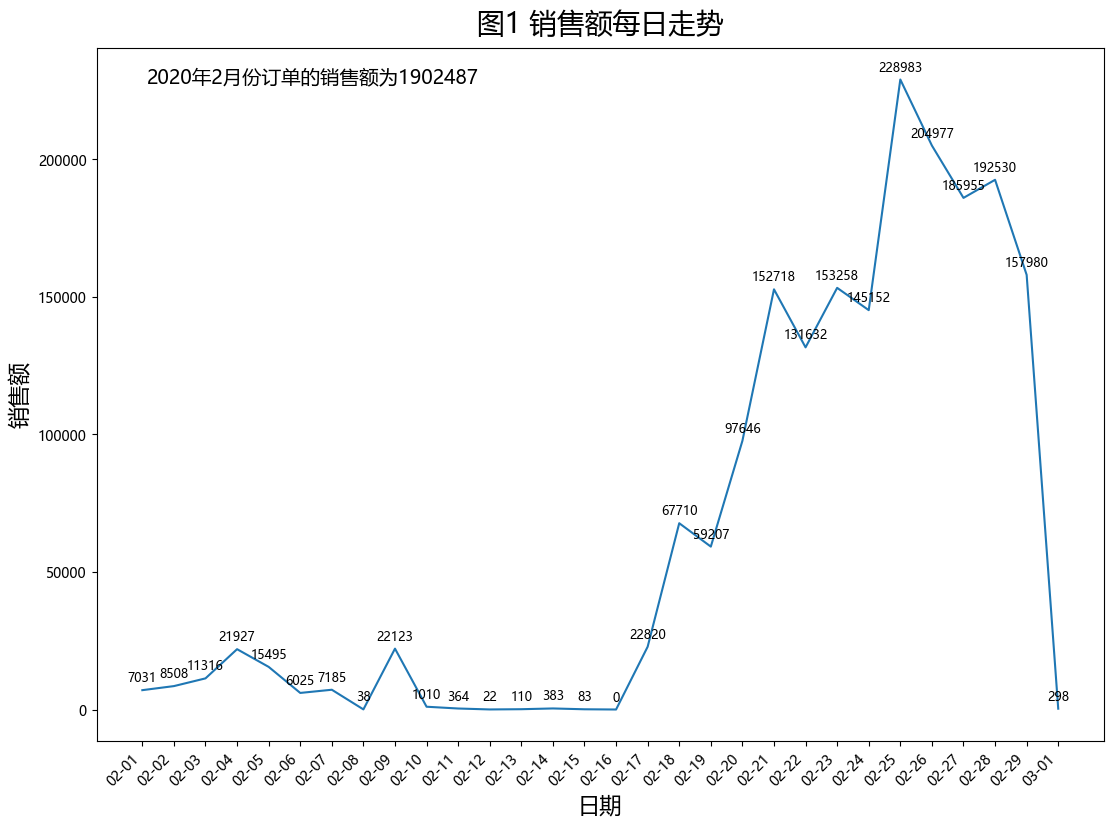

In [12]:
plt.figure(figsize=(13,9))
sns.lineplot(x=day_cost.index,y=day_cost.values)
plt.xticks(rotation=45, ha='right')
plt.text(0.05,0.95, f'2020年2月份订单的销售额为{TUS:.0f}', transform=plt.gca().transAxes, fontsize=14)
for x,y in zip(day_cost.index,day_cost.values):
    plt.text(x,y + 3000,ha='center',s=f"{y:.0f}",fontsize=9)
plt.title("图1 销售额每日走势",fontsize=20,y=1.01)
plt.xlabel("日期",fontsize=16)
plt.ylabel("销售额",fontsize=16)
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))      
ticks = plt.gca().get_xticks() 
plt.gca().set_xticks(ticks[1:-1]) 

从图1可知：
1. 2月份整体销售额约为190万
2. 4号出现局部峰值，5-8号持续下降，成交额低于万级
3. 10-16号销售量持续低于千级，真实性存疑
4. 17日后出现持续增长，25日出现本月销售峰值

假设：
1. 本月销售额目标为220万
2. 10-16日实际日均销售额为2万

### 5.2 转化率分析
从字段梳理中可以得知用户行为路径为:订单创建 ->订单付款 ->订单成交 ->订单全额成交。  
而转化率的计算方法有两种:
- 绝对转化率:每一个环节的订单数除以初始环节的订单数
- 相对转化率:每一个环节的订单数除以上一个环节的订单数

两种计算方式有各自的适用场景，本环节中，使用绝对转化率进行计算。


In [13]:
creat_num=clean_data["订单创建时间"].count()

In [14]:
pay_num=clean_data["订单付款时间"].count()

In [15]:
actualypay_num=clean_data[clean_data["买家实际支付金额"]>0].count()["买家实际支付金额"]

In [16]:
allpay_num=clean_data[clean_data["总金额"]==clean_data["买家实际支付金额"]].count()["总金额"]

In [17]:
number=pd.Series([creat_num,pay_num,actualypay_num,allpay_num],index=["创建订单","支付订单","成交订单","满额订单"])
number

创建订单    28010
支付订单    24087
成交订单    18955
满额订单    18441
dtype: int64

In [18]:
def_change_rate=number.div(creat_num)*100
def_change_rate=def_change_rate.round(2)

In [19]:
num_rate=pd.DataFrame({"订单数量":number,"绝对转化率(%)":def_change_rate})
num_rate

,订单数量,绝对转化率(%)
创建订单,28010,100.00
支付订单,24087,85.99
成交订单,18955,67.67
满额订单,18441,65.84


绘制漏斗图

In [20]:
import pyecharts.options as opts
from pyecharts.charts import Funnel

funnel = (
    Funnel()
    .add(
        "转化率",
        list(zip(num_rate.index, num_rate["绝对转化率(%)"])),
    sort_="descending",
    gap=3,
    label_opts=opts.LabelOpts(position="inside",font_size=17,formatter="{b}: {c}%")
)
   .set_global_opts(title_opts=opts.TitleOpts(title="图2 订单转化漏斗图",
                   title_textstyle_opts=opts.TextStyleOpts(font_size=20),
                   pos_left="center"),
                   legend_opts= opts.LegendOpts(is_show=False))
)

funnel.render("funnel.html")

'C:\\Users\\ZhuanZ（无密码）\\Desktop\\数据分析集\\天猫订单综合分析\\funnel.html'

In [21]:
from IPython.display import HTML
HTML("funnel.html")

根据TrustData的报告显示，淘宝2015年平时的订单成功率(指提交订单支付的支付成功率)为97.4%。若以此作为标准，本次分析当中的付款转化率85.994%低于预期标准，实际成交及全额成交的环节转化率甚至不到7成。属于比较低的水平。

### 5.3 每日付款订单走势

In [22]:
day_num=clean_data.groupby(pd.Grouper(key="订单付款时间",freq="D"))["订单付款时间"].count()
day_num

订单付款时间
2020-02-01     163
2020-02-02     199
2020-02-03     239
2020-02-04     417
2020-02-05     328
2020-02-06     128
2020-02-07     157
2020-02-08       2
2020-02-09     352
2020-02-10      24
2020-02-11      15
2020-02-12       1
2020-02-13       5
2020-02-14       7
2020-02-15       4
2020-02-16       0
2020-02-17     332
2020-02-18     846
2020-02-19     859
2020-02-20    1133
2020-02-21    1776
2020-02-22    1722
2020-02-23    1886
2020-02-24    1704
2020-02-25    2936
2020-02-26    2452
2020-02-27    2215
2020-02-28    2359
2020-02-29    1820
2020-03-01       6
Name: 订单付款时间, dtype: int64

In [23]:
tatalnum=day_num.sum()

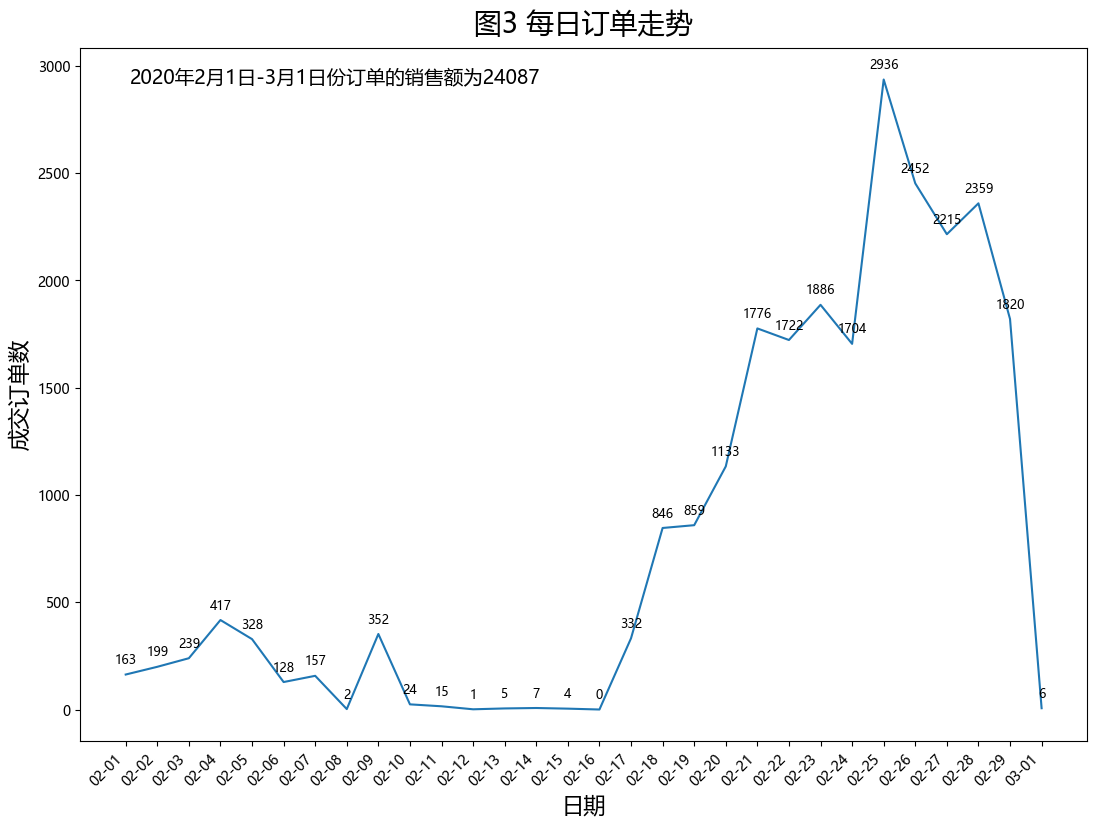

In [24]:
plt.figure(figsize=(13,9))
sns.lineplot(x=day_num.index,y=day_num.values)
plt.xticks(rotation=45, ha='right')
plt.text(0.05,0.95, f'2020年2月1日-3月1日份订单的销售额为{tatalnum:.0f}', transform=plt.gca().transAxes, fontsize=14)
for x,y in zip(day_num.index,day_num.values):
    plt.text(x,y + 50,ha='center',s=f"{y:.0f}",fontsize=9)
plt.title("图3 每日订单走势",fontsize=20,y=1.01)
plt.xlabel("日期",fontsize=16)
plt.ylabel("成交订单数",fontsize=16)
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))      
ticks = plt.gca().get_xticks() 
plt.gca().set_xticks(ticks[1:-1]) 

按照现有的转化率情况进行估算，10-16日的日均订单创建量约为300+，即2月的整体订单创建数为2万6千左右。在转化率及客单价均不变的情况下，订单创建数至少要增加多6k才能达到目标值。
值得注意17号后，订单创建量不断上升，峰值甚至接近上升前峰值的7倍。

### 5.4 区域订单数及成交金额分布

In [25]:
place_num_data=clean_data.copy()
place_num_data["收货地址"].value_counts()

收货地址
上海          3353
广东省         2463
江苏省         2126
浙江省         2061
北京          2054
四川省         2019
山东省         1804
辽宁省         1187
天津          1153
湖南省         1099
河北省         1083
重庆          1036
河南省          966
云南省          778
安徽省          609
陕西省          536
福建省          489
山西省          465
广西壮族自治区      436
江西省          411
吉林省          401
黑龙江省         379
贵州省          345
内蒙古自治区       215
海南省          178
甘肃省          167
湖北省           75
新疆维吾尔自治区      58
宁夏回族自治区       42
青海省           19
西藏自治区          3
Name: count, dtype: int64

In [26]:
place_num_data[place_num_data["收货地址"]=="西藏自治区"]

,订单编号,总金额,买家实际支付金额,收货地址,订单创建时间,订单付款时间,退款金额
3397,3398,163.72,0.0,西藏自治区,2020-02-17 23:43:55,2020-02-17 23:44:06,163.72
12893,12894,195.00,0.0,西藏自治区,2020-02-26 20:40:02,NaT,0.00
20046,20047,131.00,0.0,西藏自治区,2020-02-24 11:36:05,2020-02-24 11:36:12,131.00


In [27]:
place_num_data=place_num_data[place_num_data["买家实际支付金额"]>0]

In [28]:
actual_place_num=place_num_data.groupby("收货地址")["订单付款时间"].count()
actual_place_num=actual_place_num.sort_values(ascending=False)
actual_place_num.index

Index(['上海', '广东省', '北京', '江苏省', '浙江省', '四川省', '山东省', '天津', '辽宁省', '湖南省', '重庆',
       '河北省', '河南省', '云南省', '安徽省', '陕西省', '山西省', '福建省', '广西壮族自治区', '吉林省',
       '江西省', '黑龙江省', '贵州省', '内蒙古自治区', '海南省', '甘肃省', '宁夏回族自治区', '湖北省',
       '新疆维吾尔自治区', '青海省'],
      dtype='str', name='收货地址')

In [29]:
actual_place_num=actual_place_num.reset_index()
actual_place_num["新地址"]=((['上海', '广东', '北京', '江苏', '浙江', '四川', '山东', '天津', '辽宁', '湖南', '重庆',
'河北', '河南', '云南', '安徽', '陕西', '山西', '福建', '广西', '吉林', '江西', '黑龙江', '贵州', '内蒙古', '海南', '甘肃', '宁夏', '湖北',  '新疆', '青海']))
actual_place_num=actual_place_num.drop("收货地址",axis=1)
actual_place_num=actual_place_num.rename(columns={"订单付款时间":"有效订单"})
actual_place_num.loc[30]=pd.Series([0,"西藏"],index=["有效订单","新地址"])
actual_place_num

,有效订单,新地址
0,2470,上海
1,1585,广东
2,1489,北京
3,1459,江苏
4,1438,浙江
5,1380,四川
6,1145,山东
7,838,天津
8,812,辽宁
9,747,湖南


In [30]:
tatal_place_num=clean_data.groupby("收货地址")["订单付款时间"].count()
tatal_place_num=tatal_place_num.sort_values(ascending=False)
tatal_place_num

收货地址
上海          3060
广东省         2022
北京          1853
江苏省         1845
浙江省         1822
四川省         1752
山东省         1484
天津          1031
辽宁省         1012
湖南省          935
重庆           896
河北省          885
河南省          792
云南省          667
安徽省          528
陕西省          441
福建省          425
山西省          395
广西壮族自治区      353
吉林省          336
江西省          331
黑龙江省         312
贵州省          286
内蒙古自治区       176
海南省          156
甘肃省          132
湖北省           57
新疆维吾尔自治区      43
宁夏回族自治区       40
青海省           18
西藏自治区          2
Name: 订单付款时间, dtype: int64

In [31]:
tatal_place_num=tatal_place_num.reset_index()
tatal_place_num["新地址"]=(['上海', '广东', '北京', '江苏', '浙江', '四川', '山东', '天津', '辽宁', '湖南', '重庆', '河北', '河南', '云南', '安徽', '陕西', '福建', '山西', '广西', '吉林', '江西', '黑龙江', '贵州', '内蒙古', '海南', '甘肃', '湖北', '新疆', '宁夏', '青海', '西藏'])
tatal_place_num=tatal_place_num.drop("收货地址",axis=1)
tatal_place_num=tatal_place_num.rename(columns={"订单付款时间":"有效订单"})
tatal_place_num

,有效订单,新地址
0,3060,上海
1,2022,广东
2,1853,北京
3,1845,江苏
4,1822,浙江
5,1752,四川
6,1484,山东
7,1031,天津
8,1012,辽宁
9,935,湖南


In [32]:
place_cost=clean_data.groupby("收货地址")["买家实际支付金额"].sum()
place_cost=place_cost.sort_values(ascending=False)
place_cost

收货地址
上海          264039.78
北京          166448.48
江苏省         159359.18
广东省         147822.90
浙江省         141664.80
四川省         127648.15
山东省         103917.26
天津           89990.06
辽宁省          74692.05
重庆           71514.65
湖南省          70268.68
河北省          64374.92
河南省          56354.03
云南省          53633.84
陕西省          40484.23
安徽省          37710.06
山西省          32515.40
内蒙古自治区       28863.30
吉林省          26723.66
广西壮族自治区      23986.69
福建省          23563.27
江西省          23145.05
贵州省          21879.56
黑龙江省         21292.19
海南省          11462.58
甘肃省           9095.96
宁夏回族自治区       3716.42
新疆维吾尔自治区      2768.00
湖北省           1827.80
青海省           1724.20
西藏自治区            0.00
Name: 买家实际支付金额, dtype: float64

In [33]:
place_cost=place_cost.reset_index()
place_cost

,收货地址,买家实际支付金额
0,上海,264039.78
1,北京,166448.48
2,江苏省,159359.18
3,广东省,147822.90
4,浙江省,141664.80
5,四川省,127648.15
6,山东省,103917.26
7,天津,89990.06
8,辽宁省,74692.05
9,重庆,71514.65


In [34]:
from pyecharts.charts import Map
from IPython.display import HTML

In [35]:
actual_place_num_list=list(zip(actual_place_num["新地址"], actual_place_num["有效订单"]))
# actual_place_num_list=[list(z) for z in zip(actual_place_num["新地址"],actual_place_num["有效订单"])]
name_mapping = {
    "上海": "上海市", "北京": "北京市", "广东": "广东省", "江苏": "江苏省",
    "浙江": "浙江省", "四川": "四川省", "山东": "山东省", "天津": "天津市",
    "辽宁": "辽宁省", "湖南": "湖南省", "重庆": "重庆市", "河北": "河北省",
    "河南": "河南省", "云南": "云南省", "安徽": "安徽省", "陕西": "陕西省",
    "山西": "山西省", "福建": "福建省", "广西": "广西壮族自治区", "吉林": "吉林省",
    "江西": "江西省", "黑龙江": "黑龙江省", "贵州": "贵州省", "内蒙古": "内蒙古自治区",
    "海南": "海南省", "甘肃": "甘肃省", "宁夏": "宁夏回族自治区", "湖北": "湖北省",
    "新疆": "新疆维吾尔自治区", "青海": "青海省", "西藏": "西藏自治区"
}
actual_place_num_list = [[name_mapping[p], n] for p, n in actual_place_num_list]
actual_place_num_list

[['上海市', 2470],
 ['广东省', 1585],
 ['北京市', 1489],
 ['江苏省', 1459],
 ['浙江省', 1438],
 ['四川省', 1380],
 ['山东省', 1145],
 ['天津市', 838],
 ['辽宁省', 812],
 ['湖南省', 747],
 ['重庆市', 691],
 ['河北省', 686],
 ['河南省', 607],
 ['云南省', 528],
 ['安徽省', 392],
 ['陕西省', 359],
 ['山西省', 317],
 ['福建省', 315],
 ['广西壮族自治区', 278],
 ['吉林省', 260],
 ['江西省', 256],
 ['黑龙江省', 231],
 ['贵州省', 228],
 ['内蒙古自治区', 136],
 ['海南省', 119],
 ['甘肃省', 108],
 ['宁夏回族自治区', 32],
 ['湖北省', 18],
 ['新疆维吾尔自治区', 16],
 ['青海省', 15],
 ['西藏自治区', 0]]

In [36]:
china_map_num=(
  Map(init_opts=opts.InitOpts(width="1400px",height="700px",theme="roma"))
  .add("交易数量",
    actual_place_num_list,
    maptype="china",
    is_map_symbol_show=False,
    label_opts=opts.LabelOpts(is_show=False)
    )
   .set_global_opts(
     title_opts= opts.TitleOpts(title="图4 各省份实际订单数",   
       title_textstyle_opts=opts.TextStyleOpts(font_size=20),
       pos_left="20%",pos_top="5%"),
    legend_opts= opts.LegendOpts(is_show=False),
    visualmap_opts=opts.VisualMapOpts(  # max_=2400,
        is_piecewise=True, 
        # split_number=6,
        pieces=[
        {"min": 2000, "label": "2000以上"},
        {"min": 1500, "max": 2000, "label": "1500-2000"},
        {"min": 1000, "max": 1500, "label": "1000-1500"},
        {"min": 500, "max": 1000, "label": "500-1000"},
        {"min": 100, "max": 500, "label": "100-500"},
        {"max": 100, "label": "0-100"},
        ],
        range_text=["单",""],  
        range_color=["#d9ecf2","#a2d5f2","#e8ffc1","#a5ecd7","#51adcf","#0278ae"],
        pos_left="20%",pos_top="70%"))
    )
   
china_map_num.render("china_map_num.html")

'C:\\Users\\ZhuanZ（无密码）\\Desktop\\数据分析集\\天猫订单综合分析\\china_map_num.html'

In [49]:
from pyecharts.render import make_snapshot
HTML("china_map_num.html")

上海、广东、北京、江苏、浙江、四川、山东是有效订单的主要贡献省份，2月订单数各省均超过1000，其中，海、广东、北京位列前三，分别为2470、1585、1489单；  
西藏、青海、新疆、湖北、宁夏各省2月订单数各省均少于100，其中，西藏、青海、新疆位次靠后，分别为0、15、16单。

In [38]:
new_tatal_place_num=tatal_place_num.set_index("新地址")
new_tatal_place_num

,有效订单
新地址,
上海,3060
广东,2022
北京,1853
江苏,1845
浙江,1822
四川,1752
山东,1484
天津,1031
辽宁,1012


In [39]:
new_actual_place_num=actual_place_num.set_index("新地址")
new_actual_place_num

,有效订单
新地址,
上海,2470
广东,1585
北京,1489
江苏,1459
浙江,1438
四川,1380
山东,1145
天津,838
辽宁,812


In [40]:
rate_tatal_place_num=(new_tatal_place_num-new_actual_place_num)/new_tatal_place_num*100
rate_tatal_place_num=rate_tatal_place_num.round(2)
rate_tatal_place_num=rate_tatal_place_num.rename(columns={"有效订单":"订单无效率"})
rate_tatal_place_num

,订单无效率
新地址,
上海,19.28
云南,20.84
内蒙古,22.73
北京,19.64
吉林,22.62
四川,21.23
天津,18.72
宁夏,20.00
安徽,25.76


In [41]:
rate_tatal_place_num_list=list(zip(rate_tatal_place_num.index, rate_tatal_place_num["订单无效率"]))
rate_tatal_place_num_list= [[name_mapping[p], n] for p, n in rate_tatal_place_num_list]
rate_tatal_place_num_list

[['上海市', 19.28],
 ['云南省', 20.84],
 ['内蒙古自治区', 22.73],
 ['北京市', 19.64],
 ['吉林省', 22.62],
 ['四川省', 21.23],
 ['天津市', 18.72],
 ['宁夏回族自治区', 20.0],
 ['安徽省', 25.76],
 ['山东省', 22.84],
 ['山西省', 19.75],
 ['广东省', 21.61],
 ['广西壮族自治区', 21.25],
 ['新疆维吾尔自治区', 62.79],
 ['江苏省', 20.92],
 ['江西省', 22.66],
 ['河北省', 22.49],
 ['河南省', 23.36],
 ['浙江省', 21.08],
 ['海南省', 23.72],
 ['湖北省', 68.42],
 ['湖南省', 20.11],
 ['甘肃省', 18.18],
 ['福建省', 25.88],
 ['西藏自治区', 100.0],
 ['贵州省', 20.28],
 ['辽宁省', 19.76],
 ['重庆市', 22.88],
 ['陕西省', 18.59],
 ['青海省', 16.67],
 ['黑龙江省', 25.96]]

In [42]:
china_map_rate=(
  Map(init_opts=opts.InitOpts(width="1400px",height="700px",theme="roma"))
  .add("订单无效率",
    rate_tatal_place_num_list,
    maptype="china",
    is_map_symbol_show=False,
    label_opts=opts.LabelOpts(is_show=False)
    )
   .set_global_opts(
     title_opts= opts.TitleOpts(title="图5 各省份订单无效率",   
       title_textstyle_opts=opts.TextStyleOpts(font_size=20),
       pos_left="20%",pos_top="5%"),
    legend_opts= opts.LegendOpts(is_show=False),
    tooltip_opts=opts.TooltipOpts(formatter="{b}: {c}%" ),           
    visualmap_opts=opts.VisualMapOpts(  max_=100,min_=0,
        is_piecewise=False, 
        #split_number=6,
        range_text=["%",""],  
        range_color=["#d9ecf2","#a2d5f2","#e8ffc1","#a5ecd7","#51adcf","#0278ae"],
        pos_left="20%",pos_top="70%"))
    )
   
china_map_rate.render("china_map_rate.html")

'C:\\Users\\ZhuanZ（无密码）\\Desktop\\数据分析集\\天猫订单综合分析\\china_map_rate.html'

In [43]:
HTML("china_map_rate.html")

各省的订单无效率普遍在20%附近，其中，西藏、湖北、新疆无效率最高，分别为100%、68.42%、62.79%，下单量分别为2、43、57，在总订单中占比较小，故对总销售额影响有限。

In [44]:
place_cost["收货地址"]=place_cost["收货地址"].replace({"上海": "上海市", "北京": "北京市",  "天津": "天津市","重庆": "重庆市"})
place_cost["买家实际支付金额"]=place_cost["买家实际支付金额"].astype(int)
place_cost

,收货地址,买家实际支付金额
0,上海市,264039
1,北京市,166448
2,江苏省,159359
3,广东省,147822
4,浙江省,141664
5,四川省,127648
6,山东省,103917
7,天津市,89990
8,辽宁省,74692
9,重庆市,71514


In [45]:
place_cost_list=list(zip(place_cost["收货地址"], place_cost["买家实际支付金额"]))
place_cost_list

[('上海市', 264039),
 ('北京市', 166448),
 ('江苏省', 159359),
 ('广东省', 147822),
 ('浙江省', 141664),
 ('四川省', 127648),
 ('山东省', 103917),
 ('天津市', 89990),
 ('辽宁省', 74692),
 ('重庆市', 71514),
 ('湖南省', 70268),
 ('河北省', 64374),
 ('河南省', 56354),
 ('云南省', 53633),
 ('陕西省', 40484),
 ('安徽省', 37710),
 ('山西省', 32515),
 ('内蒙古自治区', 28863),
 ('吉林省', 26723),
 ('广西壮族自治区', 23986),
 ('福建省', 23563),
 ('江西省', 23145),
 ('贵州省', 21879),
 ('黑龙江省', 21292),
 ('海南省', 11462),
 ('甘肃省', 9095),
 ('宁夏回族自治区', 3716),
 ('新疆维吾尔自治区', 2768),
 ('湖北省', 1827),
 ('青海省', 1724),
 ('西藏自治区', 0)]

In [46]:
place_cost_list

[('上海市', 264039),
 ('北京市', 166448),
 ('江苏省', 159359),
 ('广东省', 147822),
 ('浙江省', 141664),
 ('四川省', 127648),
 ('山东省', 103917),
 ('天津市', 89990),
 ('辽宁省', 74692),
 ('重庆市', 71514),
 ('湖南省', 70268),
 ('河北省', 64374),
 ('河南省', 56354),
 ('云南省', 53633),
 ('陕西省', 40484),
 ('安徽省', 37710),
 ('山西省', 32515),
 ('内蒙古自治区', 28863),
 ('吉林省', 26723),
 ('广西壮族自治区', 23986),
 ('福建省', 23563),
 ('江西省', 23145),
 ('贵州省', 21879),
 ('黑龙江省', 21292),
 ('海南省', 11462),
 ('甘肃省', 9095),
 ('宁夏回族自治区', 3716),
 ('新疆维吾尔自治区', 2768),
 ('湖北省', 1827),
 ('青海省', 1724),
 ('西藏自治区', 0)]

In [47]:
china_map_cost=(
  Map(init_opts=opts.InitOpts(width="1400px",height="700px",theme="roma"))
  .add("买家实际支付金额",
    place_cost_list,
    maptype="china",
    is_map_symbol_show=False,
    label_opts=opts.LabelOpts(is_show=False)
    )
   .set_global_opts(
     title_opts= opts.TitleOpts(title="图6 各省份买家实际支付金额",   
       title_textstyle_opts=opts.TextStyleOpts(font_size=20),
       pos_left="20%",pos_top="5%"),
    legend_opts= opts.LegendOpts(is_show=False),
    visualmap_opts=opts.VisualMapOpts( max_=288000,
        is_piecewise=True, 
        split_number=6,
        range_text=["元",""],  
        range_color=["#d9ecf2","#a2d5f2","#e8ffc1","#a5ecd7","#51adcf","#0278ae"],
        pos_left="20%",pos_top="70%"))
    )
   
china_map_cost.render("china_map_cost.html")

'C:\\Users\\ZhuanZ（无密码）\\Desktop\\数据分析集\\天猫订单综合分析\\china_map_cost.html'

In [48]:
HTML("china_map_cost.html")


上海、北京、江苏、广东、浙江是总金额的主要贡献省市，各省2月金额均超14万，其中，上海、北京、江苏位列前三，分别为264040、166450、159360元：  
西藏、青海、湖北、新疆、宁夏各省2月金额均超14万少于5000，其中，西藏、青海、湖北位次靠后，分别为0、1724、1827元。